# 03 · Filtering, sampling and spectral inspection

**ROBT613 · Brain–Computer Interfaces** | 90–120 min

## Goal
Design and inspect EEG filters, distinguish offline and causal processing, and measure attenuation on real EEG.

**Data:** MNE EEGBCI subject 1, run 4

Run cells from top to bottom in a fresh CPU runtime. No previous notebook state is required.

## Setup
The first cell installs the tested core versions in Colab. Downloads are cached in `mne_data/`; a new Colab runtime loses that cache. A failed download is an error, never silently replaced by synthetic data.

In [1]:
# Colab: install before importing numerical libraries. Restart if pip requests it.
import sys, subprocess, os
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'mne==1.13.2', 'moabb==1.7.2'])
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score,
                             ConfusionMatrixDisplay, classification_report)
from sklearn.model_selection import (GroupKFold, cross_validate, GridSearchCV)
SEED = 613
rng = np.random.default_rng(SEED)
DATA_ROOT = Path(os.environ.get('BCI_DATA', './mne_data')).resolve()
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MNE_DATA'] = str(DATA_ROOT)
mne.set_log_level('WARNING')
plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
import importlib.metadata as metadata
print({p: metadata.version(p) for p in ['mne','moabb','numpy','scipy','scikit-learn']})
print('Dataset cache:', DATA_ROOT)

{'mne': '1.13.2', 'moabb': '1.7.2', 'numpy': '2.1.3', 'scipy': '1.15.3', 'scikit-learn': '1.6.1'}
Dataset cache: ./mne_data


## Concepts and mathematics

A finite impulse response filter computes $y[n]=\sum_{k=0}^{L-1}h[k]x[n-k]$. Its frequency response is $H(f)=\sum_k h[k]e^{-j2\pi fk/f_s}$. The transition band, not just cutoff, controls required length. A symmetric FIR has group delay $(L-1)/(2f_s)$ when used causally.

Forward–backward IIR filtering cancels phase offline but uses future samples and squares the magnitude response. It cannot be copied into a live BCI. Filtering short epochs separately creates edge artifacts; filter each continuous run before epoching and preserve run boundaries. Do not filter across a train/test temporal boundary without a guard region at least covering the effective filter support.

Welch PSD averages windowed periodograms: $\hat P(f)=K^{-1}\sum_k|\mathcal F\{w x_k\}|^2/(f_s\sum_n w[n]^2)$. Units are $V^2/Hz$. Frequency resolution is approximately $f_s/N_{FFT}$ but zero padding does not create new information. Downsampling needs anti-alias filtering. Notch only a measured line component; a 50/60 Hz notch is redundant after a sufficiently strong 30 Hz low-pass.

## Load and inspect a real run
Choose the filter for the intended paradigm. The 8–30 Hz band here is for motor imagery, not P300.

In [2]:
from mne.datasets import eegbci
files = eegbci.load_data(1, [4], path=DATA_ROOT, update_path=False)
raw = mne.io.read_raw_edf(files[0], preload=True, verbose=False)
eegbci.standardize(raw)
raw.set_montage('standard_1005')
print(raw)
print('Channel types:', set(raw.get_channel_types()))

<RawEDF | S001R04.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>
Channel types: {'eeg'}


/tmp/ipykernel_417572/3939357097.py:5: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  raw.set_montage('standard_1005')


## Compare spectra
Use the same PSD parameters before and after filtering. Decibels below are referenced to one V²/Hz.

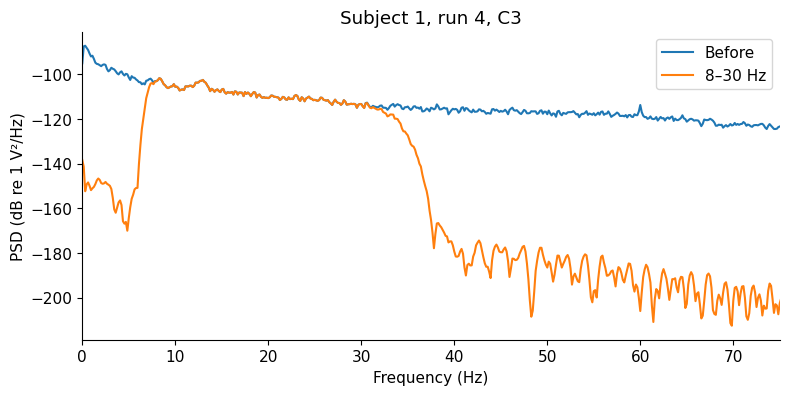

In [3]:
filtered = raw.copy().filter(8,30)
channel = raw.ch_names.index('C3')
fig, ax = plt.subplots()
for obj,name in [(raw,'Before'),(filtered,'8–30 Hz')]:
    f,p = signal.welch(obj.get_data()[channel], fs=obj.info['sfreq'], nperseg=1024)
    ax.plot(f,10*np.log10(np.maximum(p,1e-30)),label=name)
ax.set(xlim=(0,75),xlabel='Frequency (Hz)',ylabel='PSD (dB re 1 V²/Hz)',title='Subject 1, run 4, C3')
ax.legend(); plt.show()

## Inspect FIR and causal delay
An impulse exposes timing that a smooth waveform can hide.

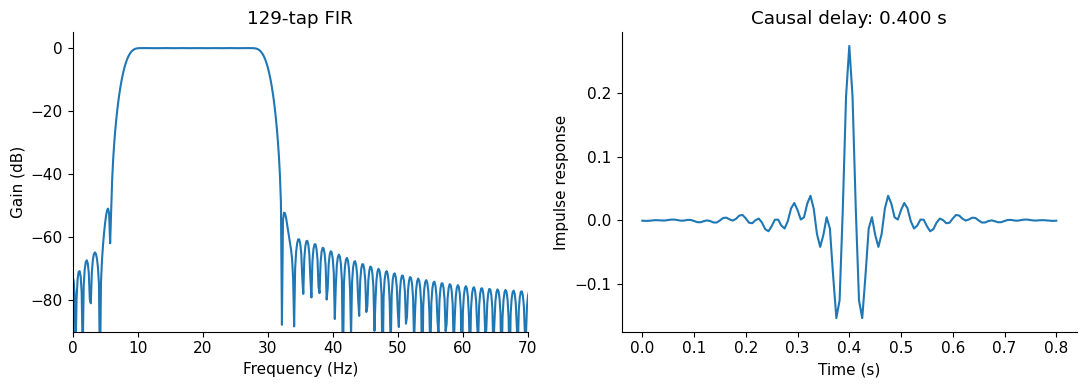

In [4]:
fs = raw.info['sfreq']
h = signal.firwin(129,[8,30],pass_zero=False,fs=fs)
f,H = signal.freqz(h,fs=fs)
fig,axes = plt.subplots(1,2,figsize=(11,4))
axes[0].plot(f,20*np.log10(np.maximum(abs(H),1e-8)))
axes[0].set(xlim=(0,70),ylim=(-90,5),xlabel='Frequency (Hz)',ylabel='Gain (dB)',title='129-tap FIR')
axes[1].plot(np.arange(len(h))/fs,h)
axes[1].set(xlabel='Time (s)',ylabel='Impulse response',title=f'Causal delay: {(len(h)-1)/(2*fs):.3f} s')
plt.tight_layout(); plt.show()
resampled = filtered.copy().resample(100)
assert resampled.info['sfreq'] == 100

## Exercises and checks
1. Compare 65 and 257 taps. Measure transition steepness and delay.
2. Why can an offline zero-phase filter create apparent pre-cue activity?
3. Apply a 0.5–20 Hz filter for P300 and explain the lower cutoff tradeoff.
4. Inspect a 50/60 Hz peak before deciding whether a notch is justified.

## Next steps and sources
[MNE filtering background](https://mne.tools/stable/auto_tutorials/preprocessing/25_background_filtering.html) · [SciPy signal](https://docs.scipy.org/doc/scipy/reference/signal.html).

Record package versions, subject/run IDs, preprocessing, split unit, random seed, and all exclusions with your results. Do not interpret a single participant as a population estimate.